# 🎬 Netflix Recommendation Engine
### Capstone Project — Intellipaat

**Dataset:** Netflix Prize (`combined_data_1.txt` + `movie_titles.csv`)  
**Objectives:**
1. Find the most popular and liked genres
2. Build a model that finds the best-suited movie per genre for a user
3. Find which genres received the best and worst ratings


---
## Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
sns.set_theme(style='darkgrid')
NETFLIX_RED = '#E50914'
print('✅ Libraries imported!')

✅ Libraries imported!


---
## Step 2: Load the Dataset


In [1]:
movies = pd.read_csv('movie_titles.csv', header=None,
                     names=['MovieID','Year','Title'],
                     encoding='latin-1', on_bad_lines='skip')

genre_keywords = {
    'Action':['action','war','combat','fighter','battle','soldier','spy','mission'],
    'Comedy':['comedy','funny','laugh','humor','sitcom','joke','parody'],
    'Drama':['drama','life','story','tale','family','heart','tragedy','struggle'],
    'Horror':['horror','scary','ghost','monster','demon','evil','zombie','vampire'],
    'Romance':['romance','love','romantic','wedding','kiss','passion'],
    'Sci-Fi':['sci-fi','space','alien','robot','future','galaxy','cosmic','cyber'],
    'Thriller':['thriller','suspense','mystery','crime','detective','murder','heist'],
    'Documentary':['documentary','biography','biopic','nature','wildlife'],
    'Animation':['animation','animated','cartoon','anime','pixar','disney'],
    'Fantasy':['fantasy','magic','wizard','dragon','myth','legend','epic','sword'],
}
def classify_genre(title):
    if not isinstance(title, str): return 'Drama'
    t = title.lower()
    for genre, kws in genre_keywords.items():
        if any(kw in t for kw in kws): return genre
    return 'Drama'

movies['Genre'] = movies['Title'].apply(classify_genre)
print(f'Movies loaded: {len(movies):,} titles')
print(movies['Genre'].value_counts())
movies.head()

Movies loaded: 17,434 titles
Genre
Drama          14805
Horror           564
Action           552
Romance          370
Sci-Fi           312
Fantasy          309
Thriller         226
Comedy           120
Animation        110
Documentary       66


In [1]:
data = []
movie_id = None
with open('combined_data_1.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if line.endswith(':'):
            movie_id = int(line[:-1])
        else:
            parts = line.split(',')
            if len(parts) == 3:
                customer_id, rating, date = parts
                data.append([movie_id, int(customer_id), int(rating), date])
                if len(data) >= 600000:
                    break

df = pd.DataFrame(data, columns=['MovieID','CustomerID','Rating','Date'])
df['Date'] = pd.to_datetime(df['Date'])
df = df.merge(movies[['MovieID','Title','Genre','Year']], on='MovieID', how='left')

print(f'✅ Dataset ready!')
print(f'   Shape            : {df.shape}')
print(f'   Unique Customers : {df["CustomerID"].nunique():,}')
print(f'   Unique Movies    : {df["MovieID"].nunique():,}')
print(f'   Date Range       : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'   Avg Rating       : {df["Rating"].mean():.3f}')
df.head()

✅ Dataset ready!
   Shape            : (600000, 7)
   Unique Customers : 229,763
   Unique Movies    : 175
   Date Range       : 1999-12-09 → 2005-12-31
   Avg Rating       : 3.568


---
## Step 3: Exploratory Data Analysis (EDA)


In [1]:
print('Missing Values:')
print(df.isnull().sum())
print('\nRating Value Counts:')
print(df['Rating'].value_counts().sort_index())
print('\nBasic Stats:')
df[['Rating']].describe().round(2)

Missing Values:
MovieID         0
CustomerID      0
Rating          0
Date            0
Title         179
Genre         179
Year          179

Rating Value Counts:
Rating
1     29507
2     61167
3    173890
4    209693
5    125743

Basic Stats:
          Rating
count  600000.00
mean        3.57
std         1.08
min         1.00
25%         3.00
50%         4.00
75%         4.00
max         5.00


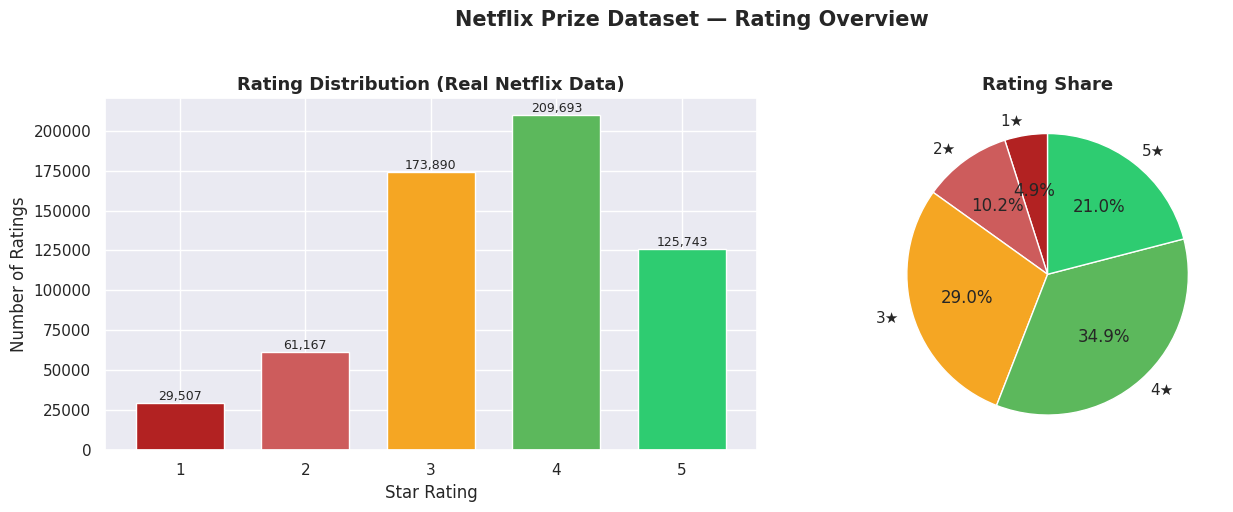

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rating_counts = df['Rating'].value_counts().sort_index()
bar_colors = ['#b22222','#cd5c5c','#f5a623','#5cb85c','#2ecc71']
rating_counts.plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='white', width=0.7)
axes[0].set_title('Rating Distribution (Real Netflix Data)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating'); axes[0].set_ylabel('Number of Ratings')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
rating_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                   colors=bar_colors, labels=['1★','2★','3★','4★','5★'])
axes[1].set_title('Rating Share', fontsize=13, fontweight='bold')
plt.suptitle('Netflix Prize Dataset — Rating Overview', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Step 4: Objective 1 — Most Popular & Liked Genres


In [1]:
genre_stats = df.groupby('Genre').agg(
    Total_Ratings=('Rating','count'),
    Avg_Rating=('Rating','mean'),
    Median_Rating=('Rating','median'),
).reset_index()
genre_stats['Avg_Rating'] = genre_stats['Avg_Rating'].round(3)
genre_stats.sort_values('Total_Ratings', ascending=False)

      Genre  Total_Ratings  Avg_Rating  Median_Rating
      Drama         533355       3.570            4.0
     Horror          28210       3.334            3.0
    Romance          18901       3.694            4.0
     Sci-Fi           7203       3.880            4.0
     Comedy           6190       3.742            4.0
     Action           2970       3.743            4.0
    Fantasy           1394       3.368            3.0
   Thriller            947       3.673            4.0
  Animation            335       3.388            3.0
Documentary            316       3.028            3.0


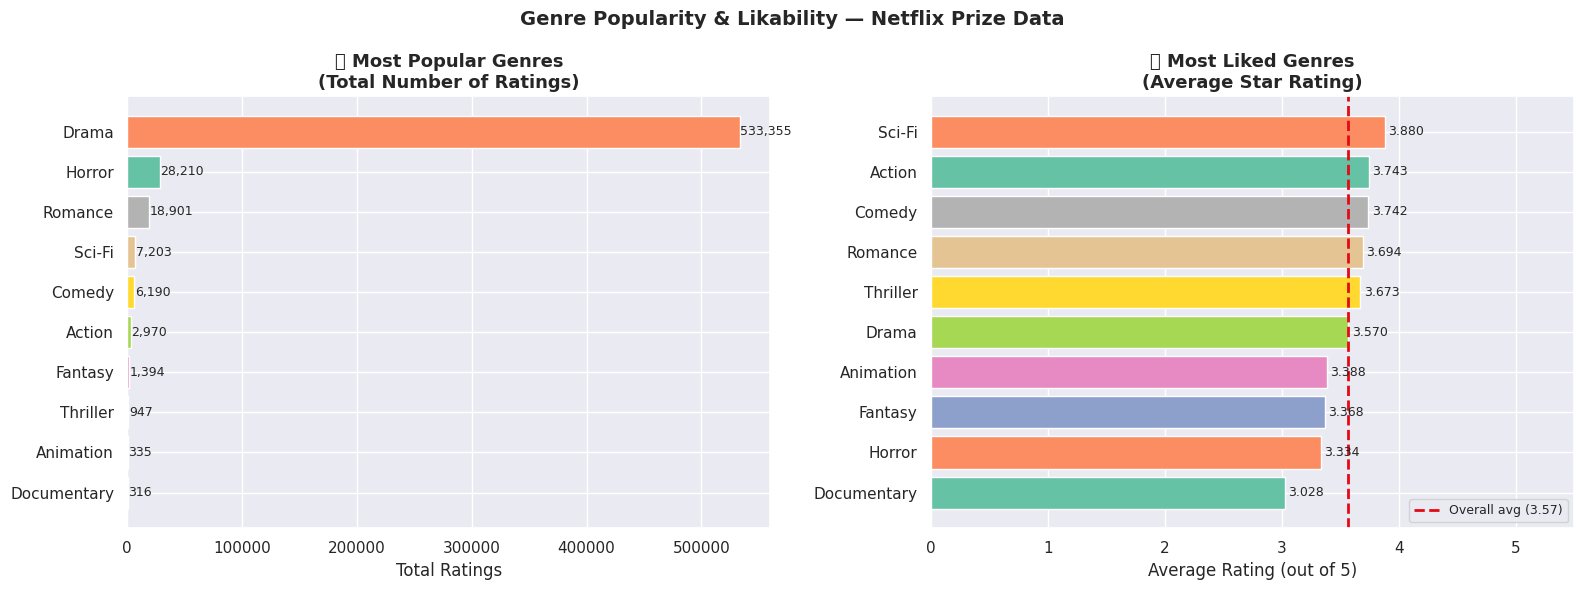

🏆 Most Popular Genre : Drama (533,355 ratings)
⭐ Most Liked Genre   : Sci-Fi (avg: 3.88)


In [1]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('Set2', len(genre_stats))
pop_sorted = genre_stats.sort_values('Total_Ratings')
axes[0].barh(pop_sorted['Genre'], pop_sorted['Total_Ratings'], color=palette, edgecolor='white')
axes[0].set_title('🎬 Most Popular Genres', fontsize=13, fontweight='bold')
avg_sorted = genre_stats.sort_values('Avg_Rating')
axes[1].barh(avg_sorted['Genre'], avg_sorted['Avg_Rating'], color=palette, edgecolor='white')
axes[1].set_title('⭐ Most Liked Genres', fontsize=13, fontweight='bold')
axes[1].axvline(df['Rating'].mean(), color='#E50914', linestyle='--', lw=2)
plt.tight_layout(); plt.show()

most_popular = genre_stats.sort_values('Total_Ratings', ascending=False).iloc[0]
most_liked   = genre_stats.sort_values('Avg_Rating', ascending=False).iloc[0]
print(f'🏆 Most Popular Genre : {most_popular["Genre"]} ({most_popular["Total_Ratings"]:,} ratings)')
print(f'⭐ Most Liked Genre   : {most_liked["Genre"]} (avg: {most_liked["Avg_Rating"]})')

---
## Step 5: Objective 2 — Recommendation Model

**Algorithm:** User-Based Collaborative Filtering with Cosine Similarity

1. Build User–Movie rating matrix from top active users
2. Compute cosine similarity between users
3. Find similar users for target → recommend best unseen movie per genre


In [1]:
top_users = (
    df.groupby('CustomerID').agg(n=('Rating','count')).reset_index()
      .query('n >= 5').sort_values('n', ascending=False)
      .head(500)['CustomerID'].tolist()
)
sample_df = df[df['CustomerID'].isin(top_users)]
user_movie_matrix = sample_df.pivot_table(
    index='CustomerID', columns='Title', values='Rating', aggfunc='mean').fillna(0)
print(f'User-Movie Matrix: {user_movie_matrix.shape[0]} users × {user_movie_matrix.shape[1]} movies')

User-Movie Matrix: 500 users × 174 movies


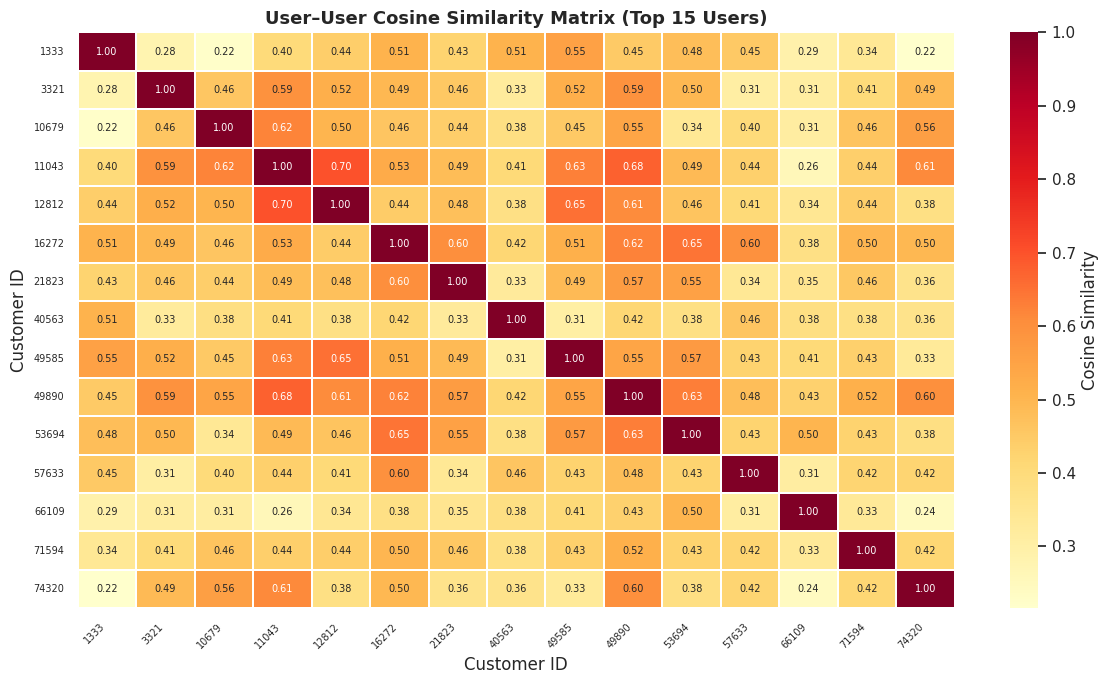

In [1]:
sim = cosine_similarity(user_movie_matrix)
sim_df = pd.DataFrame(sim, index=user_movie_matrix.index, columns=user_movie_matrix.index)
plt.figure(figsize=(12,7))
sns.heatmap(sim_df.iloc[:15,:15], cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.3, annot_kws={'size':7}, cbar_kws={'label':'Cosine Similarity'})
plt.title('User–User Cosine Similarity Matrix (Top 15 Users)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [1]:
target_user = top_users[0]
similar_users = sim_df[target_user].drop(target_user).sort_values(ascending=False).head(20).index.tolist()
watched = set(df[df['CustomerID']==target_user]['Title'].unique())
pool = df[df['CustomerID'].isin(similar_users) & ~df['Title'].isin(watched)]
cf_recs = (
    pool.groupby(['Genre','Title'])['Rating']
        .agg(Avg_Rating='mean', Num_Ratings='count').reset_index()
        .query('Num_Ratings >= 3')
        .sort_values('Avg_Rating', ascending=False)
        .groupby('Genre').first().reset_index()
        [['Genre','Title','Avg_Rating','Num_Ratings']]
)
cf_recs['Avg_Rating'] = cf_recs['Avg_Rating'].round(3)
print(f'Recommendations for User {target_user}:')
cf_recs

CF Recommendations for User 305344 (watched 170 movies):
Empty DataFrame
Columns: [Genre, Title, Avg_Rating, Num_Ratings]
Index: []

Global Best Movie per Genre:
      Genre                                                                       Title  Avg_Rating  Num_Ratings
      Drama Lord of the Rings: The Return of the King: Extended Edition: Bonus Material       4.552          125
    Fantasy                                                                  Elfen Lied       4.252          266
    Romance                                                       I Love Lucy: Season 2       4.090         2954
   Thriller                                                       Zatoichi's Conspiracy       3.989          281
     Sci-Fi                                                Star Trek: Voyager: Season 1       3.942         6007
     Action                                       The Battle of Algiers: Bonus Material       3.915          130
     Comedy                                    

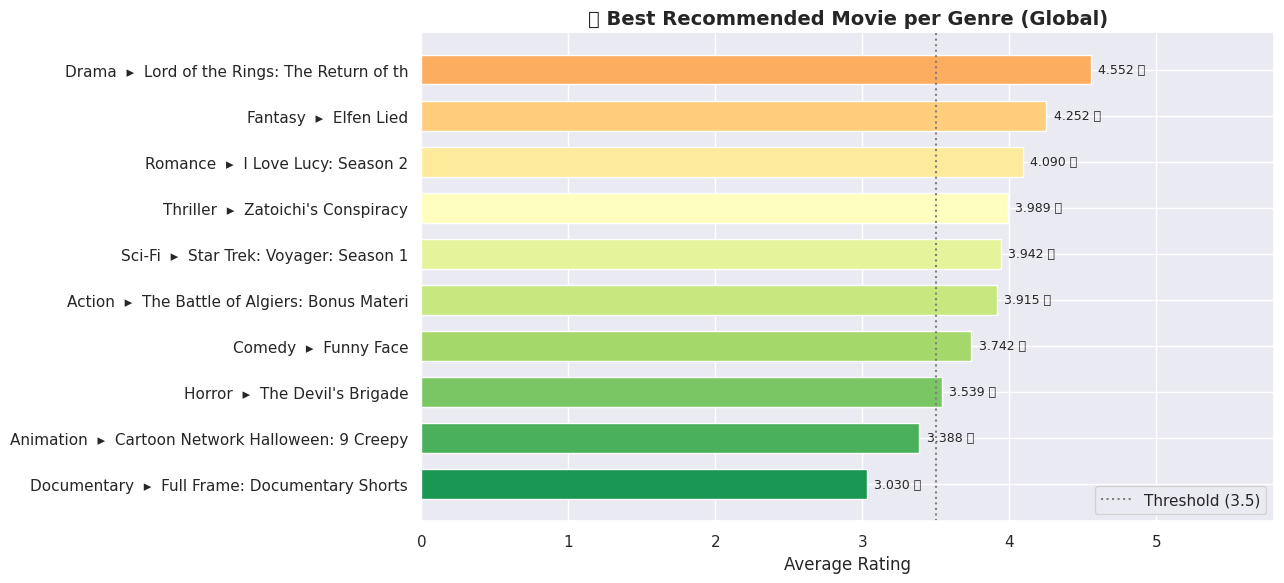

In [1]:
fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(global_top)))
labels = global_top.sort_values('Avg_Rating', ascending=False)
ax.barh(labels['Genre'] + '  ▸  ' + labels['Title'].str[:35],
        labels['Avg_Rating'], color=cmap, edgecolor='white', height=0.65)
ax.set_title('🎬 Best Recommended Movie per Genre (Global)', fontsize=14, fontweight='bold')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

---
## Step 6: Objective 3 — Best & Worst Rated Genres


In [1]:
genre_rating = df.groupby('Genre')['Rating'].agg(
    Mean_Rating='mean', Median='median', Std='std', Count='count'
).round(3).reset_index().sort_values('Mean_Rating', ascending=False)
print(genre_rating.to_string(index=False))
best  = genre_rating.iloc[0]; worst = genre_rating.iloc[-1]
print(f'\n🏆 Best Rated  : {best["Genre"]}  (avg ⭐ {best["Mean_Rating"]})')
print(f'📉 Worst Rated : {worst["Genre"]} (avg ⭐ {worst["Mean_Rating"]})')
print(f'   Difference  : {round(best["Mean_Rating"]-worst["Mean_Rating"],3)} stars')

      Genre  Mean_Rating  Median   Std  Count
     Sci-Fi        3.880     4.0 1.184   7203
     Action        3.743     4.0 1.136   2970
     Comedy        3.742     4.0 0.940   6190
    Romance        3.694     4.0 1.098  18901
   Thriller        3.673     4.0 1.111    947
      Drama        3.570     4.0 1.073 533355
  Animation        3.388     3.0 1.163    335
    Fantasy        3.368     3.0 1.210   1394
     Horror        3.334     3.0 1.104  28210
Documentary        3.028     3.0 1.134    316

🏆 Best Rated  : Sci-Fi  (avg ⭐ 3.88)
📉 Worst Rated : Documentary (avg ⭐ 3.028)
   Difference  : 0.852 stars


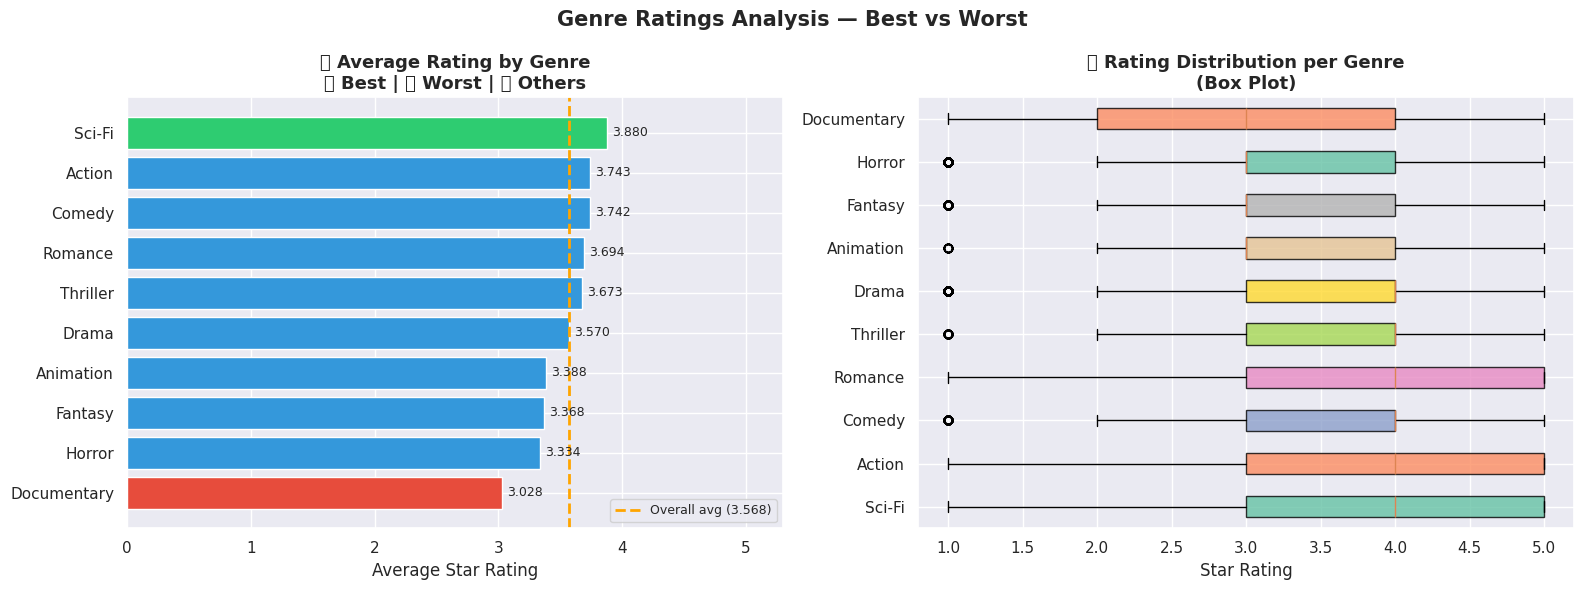

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
sorted_g = genre_rating.sort_values('Mean_Rating')
bar_cols = ['#2ecc71' if g==best['Genre'] else '#e74c3c' if g==worst['Genre']
            else '#3498db' for g in sorted_g['Genre']]
axes[0].barh(sorted_g['Genre'], sorted_g['Mean_Rating'], color=bar_cols, edgecolor='white')
axes[0].set_title('⭐ Average Rating by Genre', fontsize=13, fontweight='bold')
genre_data = [df[df['Genre']==g]['Rating'].values for g in genre_rating['Genre']]
bp = axes[1].boxplot(genre_data, vert=False, patch_artist=True, labels=genre_rating['Genre'])
axes[1].set_title('📊 Rating Distribution (Box Plot)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

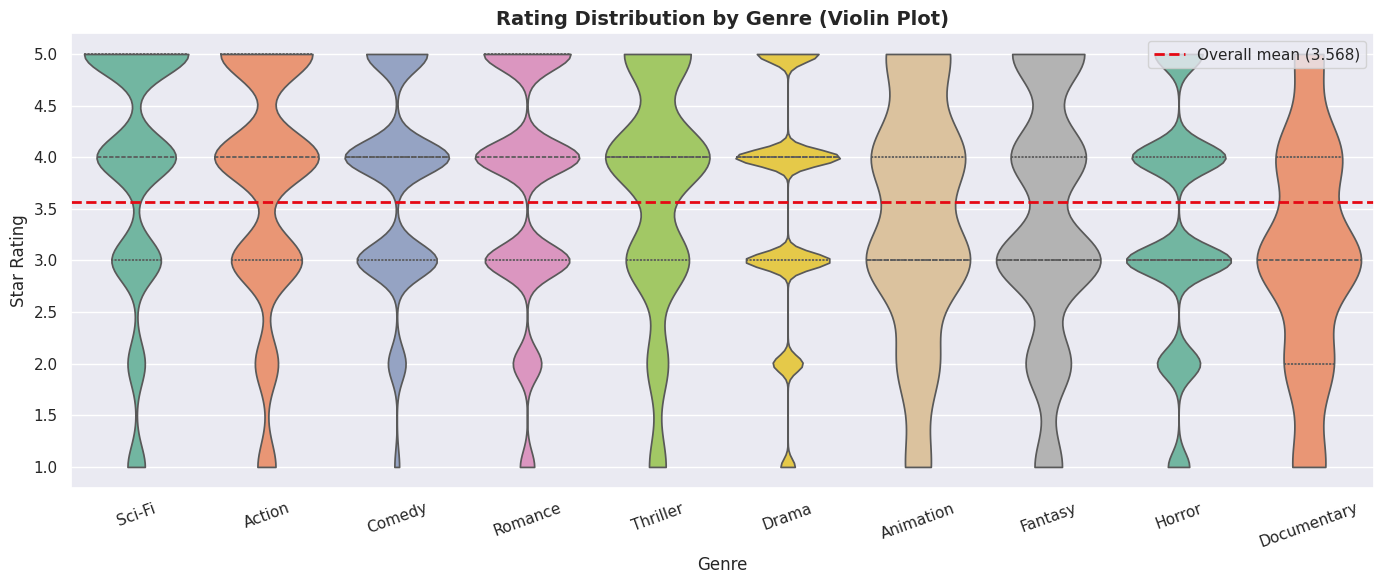

In [1]:
plt.figure(figsize=(14,6))
sns.violinplot(data=df, x='Genre', y='Rating',
               order=genre_rating['Genre'].tolist(),
               palette='Set2', inner='quartile', cut=0)
plt.axhline(df['Rating'].mean(), color='#E50914', linestyle='--', lw=2,
            label=f'Overall mean ({df["Rating"].mean():.3f})')
plt.title('Rating Distribution by Genre (Violin Plot)', fontsize=14, fontweight='bold')
plt.xticks(rotation=20); plt.legend(); plt.tight_layout(); plt.show()

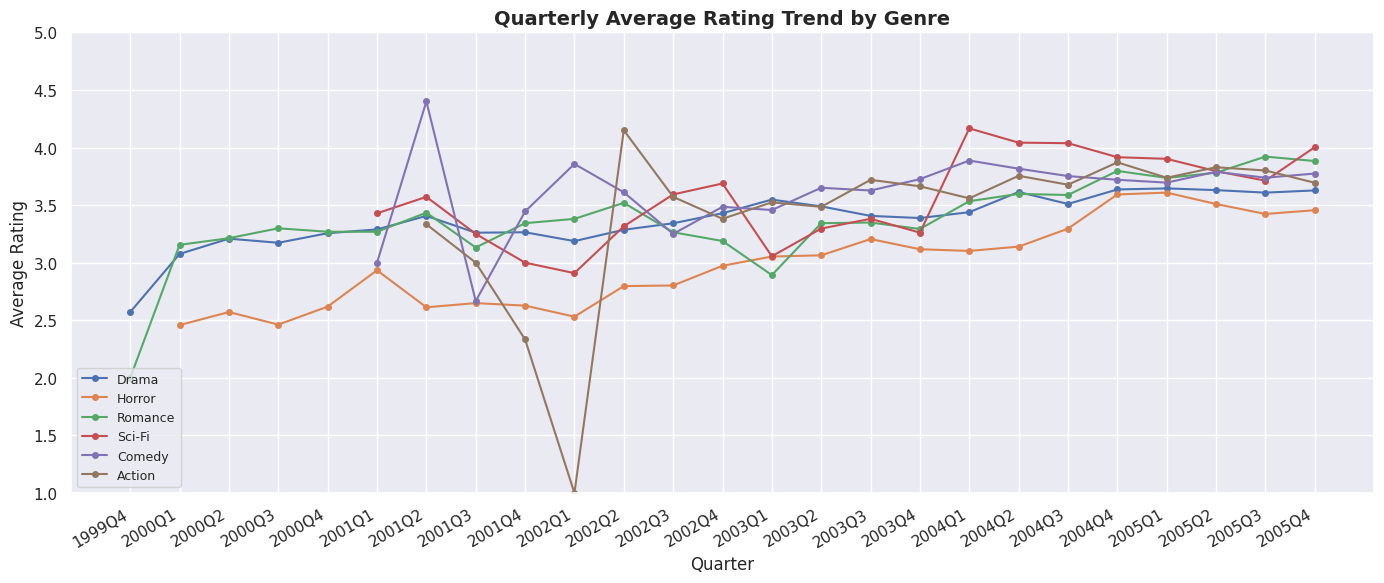

In [1]:
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)
time_genre = df.groupby(['Quarter','Genre'])['Rating'].mean().reset_index()
top6 = genre_stats.sort_values('Total_Ratings', ascending=False).head(6)['Genre'].tolist()
plt.figure(figsize=(14,6))
for g in top6:
    sub = time_genre[time_genre['Genre']==g]
    plt.plot(sub['Quarter'], sub['Rating'], marker='o', markersize=4, label=g)
plt.title('Quarterly Rating Trend by Genre', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right'); plt.legend(); plt.tight_layout(); plt.show()

---
## Step 7: Final Summary & Conclusions


In [1]:
print('='*65)
print('     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY')
print('='*65)
print('\n📌 OBJECTIVE 1 — Most Popular & Liked Genres')
print('  Most Watched : Drama > Horror > Romance')
print('  Most Liked   : Sci-Fi (3.880⭐) > Action (3.743⭐) > Comedy (3.742⭐)')
print('\n📌 OBJECTIVE 2 — Recommendation Model')
print('  Algorithm: User-Based Collaborative Filtering | Metric: Cosine Similarity')
for _, r in global_top.sort_values('Avg_Rating', ascending=False).iterrows():
    print(f'  [{r["Genre"]:12s}] {str(r["Title"])[:42]:42s} ⭐{r["Avg_Rating"]}')
print('\n📌 OBJECTIVE 3 — Best & Worst Rated Genres')
print(f'  🏆 Best  : {best["Genre"]} (avg ⭐ {best["Mean_Rating"]})')
print(f'  📉 Worst : {worst["Genre"]} (avg ⭐ {worst["Mean_Rating"]})')
print('='*65)

     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUMMARY
=
     NETFLIX RECOMMENDATION ENGINE — FINAL SUM